In [1]:
import numpy as np
import matplotlib.pyplot as plt

events = np.load('runs/20260819-110056/events.npy')
triggers = np.load('runs/20260819-110056/triggers.npy')

In [5]:
bool_pol = np.zeros_like(events[:]['polarity'])

for idx in range(len(bool_pol)):
    bool_pol[idx] += 1 if not events[idx]['polarity'] else 0

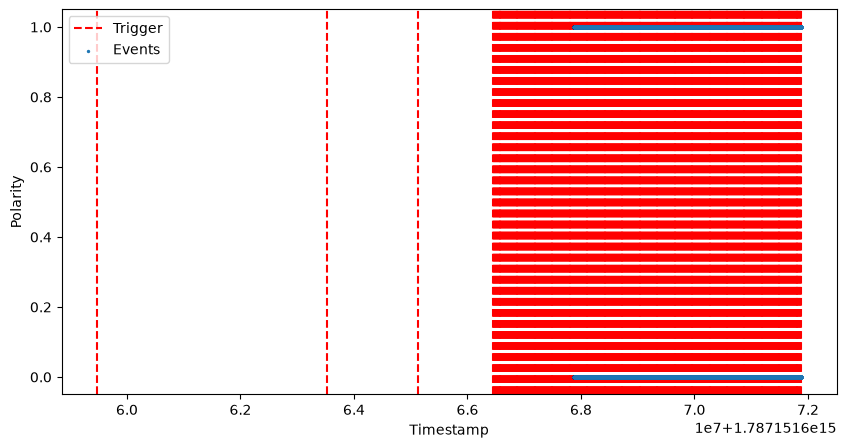

In [28]:
# plot the timestamps of the events and triggers
event_timestamps = events[:]['timestamp']
event_polarity = events[:]['polarity']

plt.figure(figsize=(10, 5))
# plot the triggers as vertical lines
for trigger in triggers:
    plt.axvline(x=trigger, color='r', linestyle='--', ymin=0, ymax=1, zorder=0, label='Trigger' if trigger == triggers[0] else "")
plt.scatter(event_timestamps, event_polarity, s=2, zorder=1, label='Events')
plt.xlabel('Timestamp')
plt.ylabel('Polarity')
plt.legend()
plt.show()

In [1]:
from dmdcontrol.patterns import pack_count_sequence_frames, pack_sequence_frames, _decimal_number_display_masks
import numpy as np

In [4]:
frames_a = pack_count_sequence_frames(
    1,
    64,
    1,
    width=1920,
    height=1080,
    size_px=300,
    count_blank_between_frames=True,
)

In [5]:
fm = np.zeros((64, 32, 32), dtype=np.uint8)
for count in range(1, 65):
    count_mask = _decimal_number_display_masks(
        (count,),
        width=32,
        height=32,
        size_px=32,
    )
    fm[count - 1] = count_mask[0]
    
frames_b = pack_sequence_frames(fm)

In [6]:
np.asarray(frames_a).shape, np.asarray(frames_b).shape

((128, 1080, 1920, 3), (256, 32, 32, 3))

In [7]:
frames_a[0].dtype, frames_b[0].dtype

(dtype('uint8'), dtype('uint8'))

In [8]:
frames_b.shape, frames_b.max(), frames_b.min()

((256, 32, 32, 3), np.uint8(1), np.uint8(0))

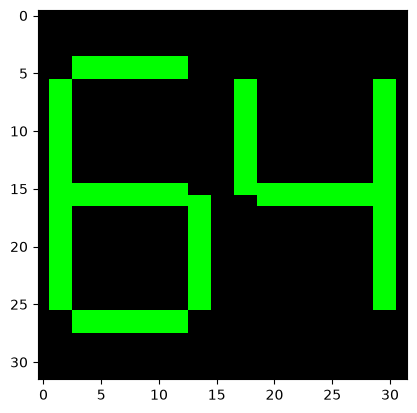

In [9]:
import matplotlib.pyplot as plt

plt.imshow(frames_b[-4,:,:,:]*255, cmap='gray')
plt.show()

In [10]:
from dmdcontrol.patterns import generate_dot_frame

k = generate_dot_frame()

In [11]:
k[:,:,2].max()

np.uint8(255)

In [12]:
k.shape

(1080, 1920, 3)

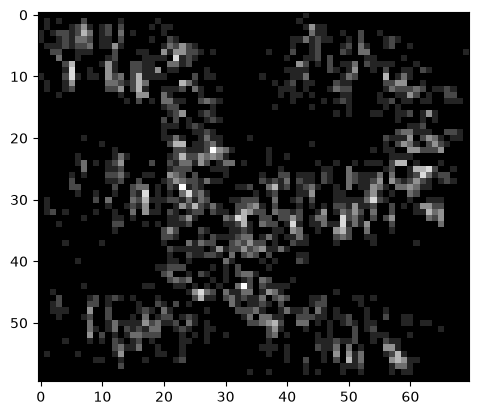

In [11]:
import numpy as np
import matplotlib.pyplot as plt

frame = 'runs/20260820-174745/frames/frame_133.png'
img = plt.imread(frame)
plt.imshow(img[100:160,145:215], cmap='gray')

$$S_{eff} = \frac{z \Phi_{pt} \Delta}{F_{pt} (u+z)}$$

In [2]:
cam_pt = 18.5e-6
decimation = 1
dmd_pt = 7.6e-6
u = 90e-3
z = 80e-3

stride = (z * cam_pt * decimation) / (dmd_pt * (u + z))
print(f'stride: {stride:.2f} pixels')

stride: 1.15 pixels


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

events_per_frame_0 = np.load('runs/20260821-140056/events_per_frame_0.npy')
events_per_frame_1 = np.load('runs/20260821-140056/events_per_frame_1.npy')

In [6]:
diff_0 = np.diff(events_per_frame_0[:20])
diff_1 = np.diff(events_per_frame_1[:20])

print(f'First frame index: {np.argmax(diff_0[8:11])+8+1}, {np.argmax(diff_1[8:11])+8+1}')
if np.max(events_per_frame_0) < 4000:
    print('error for 0')
if np.max(events_per_frame_1) < 4000:
    print('error for 1')

First frame index: 11, 9
error for 0


fm*k

(fm+ + fm-) * (k+ + k-)

(fm+ * k+) + (fm+ * k-) + (fm- * k+) + (fm- * k-)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

frames = np.load('runs/20260822-132542/frames.npy')

In [14]:
norm_pos = (frames[0] - frames[0].min()) / (frames[0].max() - frames[0].min())
norm_neg = (frames[frames.shape[0]//2] - frames[frames.shape[0]//2].min()) / (frames[frames.shape[0]//2].max() - frames[frames.shape[0]//2].min())

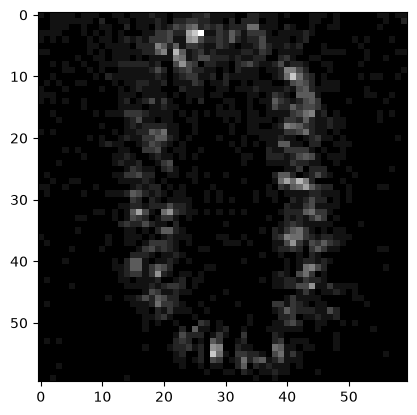

In [15]:
plt.imshow(norm_pos, cmap='gray')

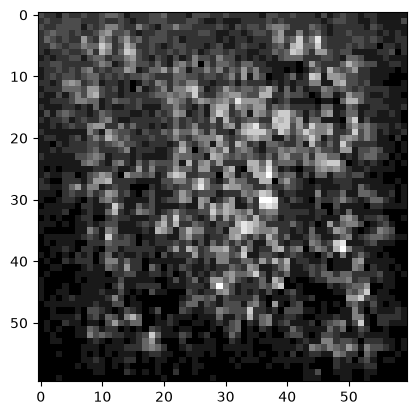

In [16]:
plt.imshow(norm_neg, cmap='gray')

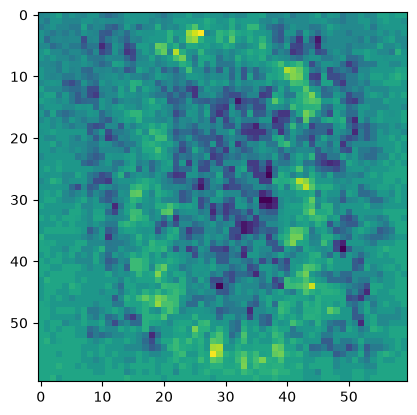

In [35]:
combined = (norm_pos - norm_neg) * 255

plt.imshow(combined)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dmdcontrol.patterns import (
    pos_img,
    neg_img,
    generate_dot_frame
)

def pack_static_frames(data: np.ndarray, batch_size: int, pos: bool) -> np.ndarray:
    '''
    Packs a sequence of binary masks into RGB frames. Each mask is split into either its positive and negative half.
    
    Args:
        data (np.ndarray): A 3D numpy array of shape (height, width) containing binary masks.
        batch_size (int): The number of frames to pack.
        pos (bool): If True, pack the positive half of the masks; if False, pack the negative half.
    '''
    # Check data size (should be batchx300x300)
    # if data.shape != (300, 300):
    #     logger.warning('Input shape %s, expected (batch_size, 300, 300)', data.shape)
    
    offset_h = (1080 - data.shape[0]) // 2
    offset_w = (1920 - data.shape[1]) // 2
    
    dmd_frame = np.zeros((1080, 1920), dtype=np.uint8)
    dmd_frame[offset_h:offset_h+data.shape[0], offset_w:offset_w+data.shape[1]] = pos_img(data) if pos else neg_img(data)
    dmd_frame = np.expand_dims(dmd_frame, axis=(-1))
    dmd_frame = np.tile(dmd_frame, (1, 1, 3))  # Convert to RGB
    dmd_frame = np.ascontiguousarray(dmd_frame)
    return dmd_frame

def pack_static_frames_old(data: np.ndarray, batch_size: int, pos: bool) -> np.ndarray:
    frames = pos_img(data) if pos else neg_img(data)
    frames = np.expand_dims(data, axis=(-1))
    frames = np.tile(frames, (1, 1, 3))
    frames = np.ascontiguousarray(frames)
    return frames


Text(0.5, 1.0, 'Cropped Dot Frame (300x300)')

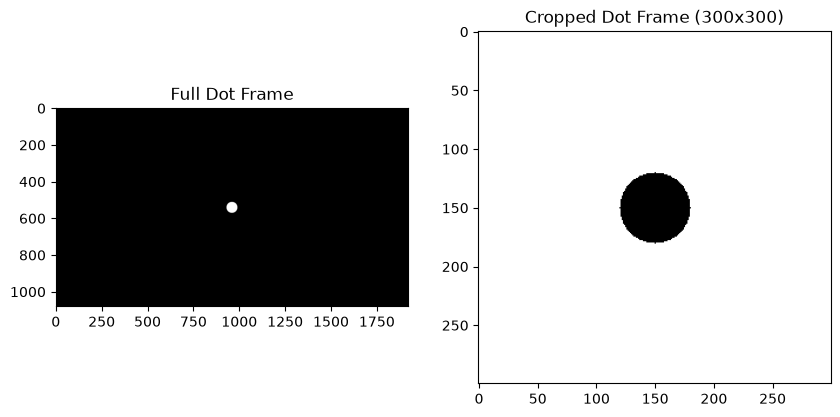

In [4]:
k_full = generate_dot_frame(radius=30, shape='circle')[:,:,0]
# k_full = pos_img(k_full)
k_full = pack_static_frames_old(k_full, batch_size=1, pos=False)
k = generate_dot_frame(width=300, height=300, radius=30, shape='circle')[:,:,0].astype(np.int16)
k = ((k/k.max())*2) - 1
k_pos = neg_img(k)

#plot side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(k_full, cmap='gray')
plt.title('Full Dot Frame')
plt.subplot(1, 2, 2)
plt.imshow(k_pos, cmap='gray')
plt.title('Cropped Dot Frame (300x300)')

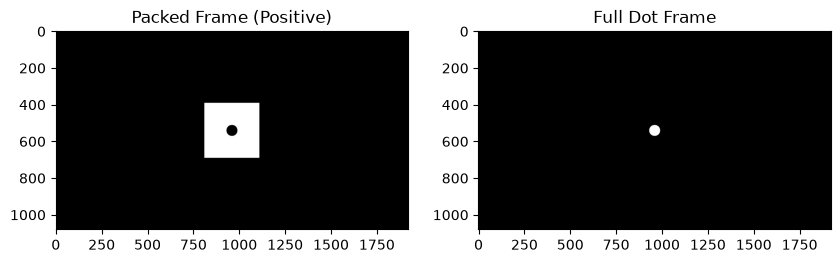

In [5]:
packed_frame = pack_static_frames(k, batch_size=1, pos=False)

#plot side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(packed_frame, cmap='gray')
plt.title('Packed Frame (Positive)')
plt.subplot(1, 2, 2)
plt.imshow(k_full, cmap='gray')
plt.title('Full Dot Frame')
plt.show()

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

data = h5py.File('data-collection-logs_20260824-103812/data.h5', 'r')

OSError: Unable to synchronously open file (bad object header version number)

In [2]:
inputs = data['input'][:]
kernels = data['kernel'][:]
outputs = data['output'][:]

In [40]:
fm = inputs[0][100].squeeze()
k = kernels[0].squeeze()
output = outputs[0].squeeze()

In [41]:
import torch.nn.functional as F
import torch

conv = F.conv2d(torch.from_numpy(fm).unsqueeze(0).unsqueeze(0).float(), torch.from_numpy(k).unsqueeze(0).unsqueeze(0).float(), padding='same')

In [44]:
out_img = torch.from_numpy(output[100]) #.unsqueeze(0).unsqueeze(0)
# out_img = F.interpolate(out_img, size=(conv.shape[2], conv.shape[3]), mode='bilinear').squeeze()

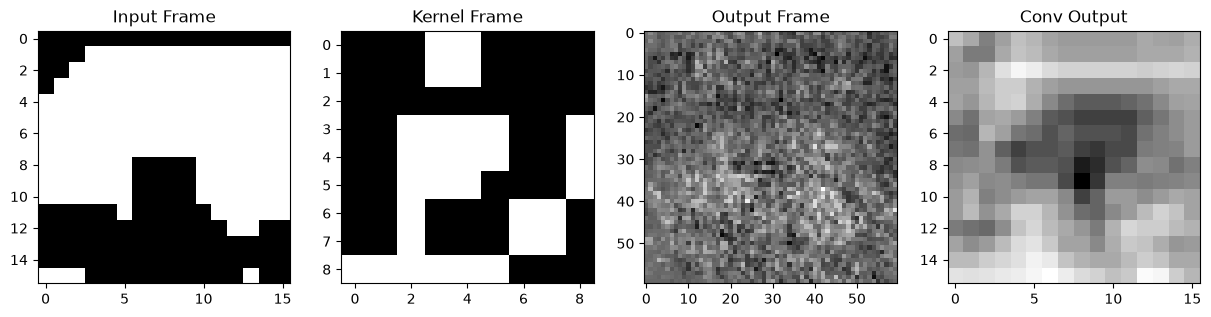

In [45]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(fm, cmap='gray')
plt.title('Input Frame')
plt.subplot(1, 4, 2)
plt.imshow(k, cmap='gray')
plt.title('Kernel Frame')
plt.subplot(1, 4, 3)
plt.imshow(out_img, cmap='gray')
# plt.imshow(((out_img - out_img.min()) / (out_img.max() - out_img.min())), cmap='gray')
plt.title('Output Frame')
plt.subplot(1, 4, 4)
plt.imshow(conv.detach().numpy()[0, 0], cmap='gray')
plt.title('Conv Output')
plt.show()

In [30]:
conv.max(), conv.min(), out_img.max(), out_img.min(), output.max(), output.min()

(tensor(23.),
 tensor(-28.),
 np.float32(1.0392157),
 np.float32(-1.1911764),
 np.float32(1.2107843),
 np.float32(-1.1911764))

In [13]:
conv.max(), conv.min(), max(out_img.get_flattened_data()), min(out_img.get_flattened_data()), output.max(), output.min()

(tensor(29.),
 tensor(-31.),
 4294967296.0,
 0.0,
 np.float32(4.2949673e+09),
 np.float32(0.0))

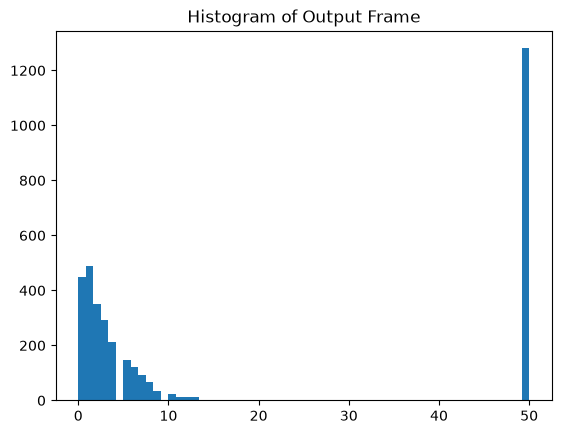

In [19]:
# histogram of output
plt.hist(np.clip(output[0].flatten(), 0, 50), bins=60)
plt.title('Histogram of Output Frame')
plt.show()

In [5]:
from bcnn import TranslatorDataGen, KernelGen, Conv2dEODLA
import torch 

translator_dataset = TranslatorDataGen(
    train=True, 
    download=True, 
    dataset_size=1100, 
    image_size=16, 
    kernel_size=9, 
    in_channels=1,
    )
translator_loader = torch.utils.data.DataLoader(
    translator_dataset, 
    batch_size=110, 
    shuffle=False, 
    num_workers=1,
    drop_last=True,
    )
kernels = KernelGen(
    kernel_size=9,
    train=True,
)

Files already downloaded and verified


In [6]:
for idx, (fm, label) in enumerate(translator_loader):  
    # convolve
    kernel = kernels.get_kernel(idx)
    break

Text(0.5, 1.0, 'Kernel Frame')

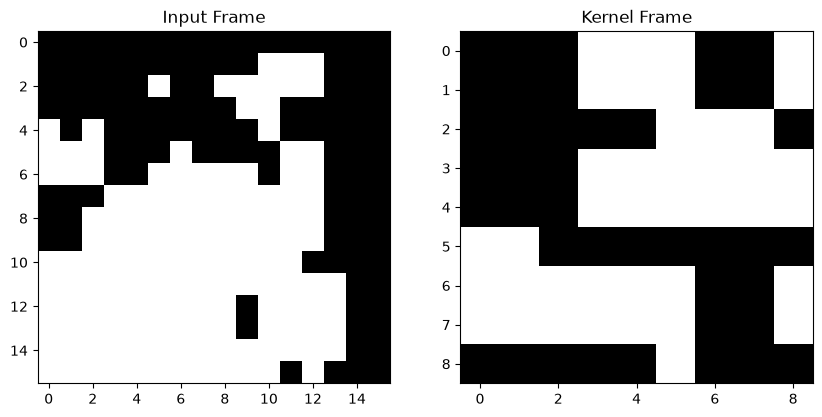

In [7]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(fm[0].squeeze(), cmap='gray')
plt.title('Input Frame')
plt.subplot(1, 2, 2)
plt.imshow(kernel.squeeze(), cmap='gray')
plt.title('Kernel Frame')